## Estimating missing purchases

The JSON stream does not provide all the data. The stream is refreshed every 10-12 minutes, but is limited to 200 records. If more lootbox purchases happen during that interval, these will not be shown. This will happen during peak hours. We can estimate the total purchase volume from the date and time of the first 200 records in that interval.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#import seaborn as sns
import datetime

In [2]:
# Load dataframes
df_purchases = pd.read_pickle("../processed_dataframes/df_purchases.pkl")
print(df_purchases.shape)
print(df_purchases.info())

(5318391, 6)
<class 'pandas.core.frame.DataFrame'>
Int64Index: 5318391 entries, 0 to 5322790
Data columns (total 6 columns):
 #   Column     Dtype 
---  ------     ----- 
 0   datetime   object
 1   timestamp  int64 
 2   user       object
 3   src        object
 4   out        object
 5   time       int64 
dtypes: int64(2), object(4)
memory usage: 284.0+ MB
None


,timestamp,user,src,out,time
datetime,,,,,
2023-08-13 22:39:00,0,0,0,0,0
2023-08-13 22:40:00,0,0,0,0,0
2023-08-13 22:41:00,0,0,0,0,0
2023-08-13 22:42:00,0,0,0,0,0
2023-08-13 22:43:00,0,0,0,0,0
2023-08-13 22:44:00,0,0,0,0,0
2023-08-13 22:45:00,37,37,37,37,37
2023-08-13 22:46:00,73,73,73,73,73
2023-08-13 22:47:00,72,72,72,72,72


<AxesSubplot: xlabel='datetime'>

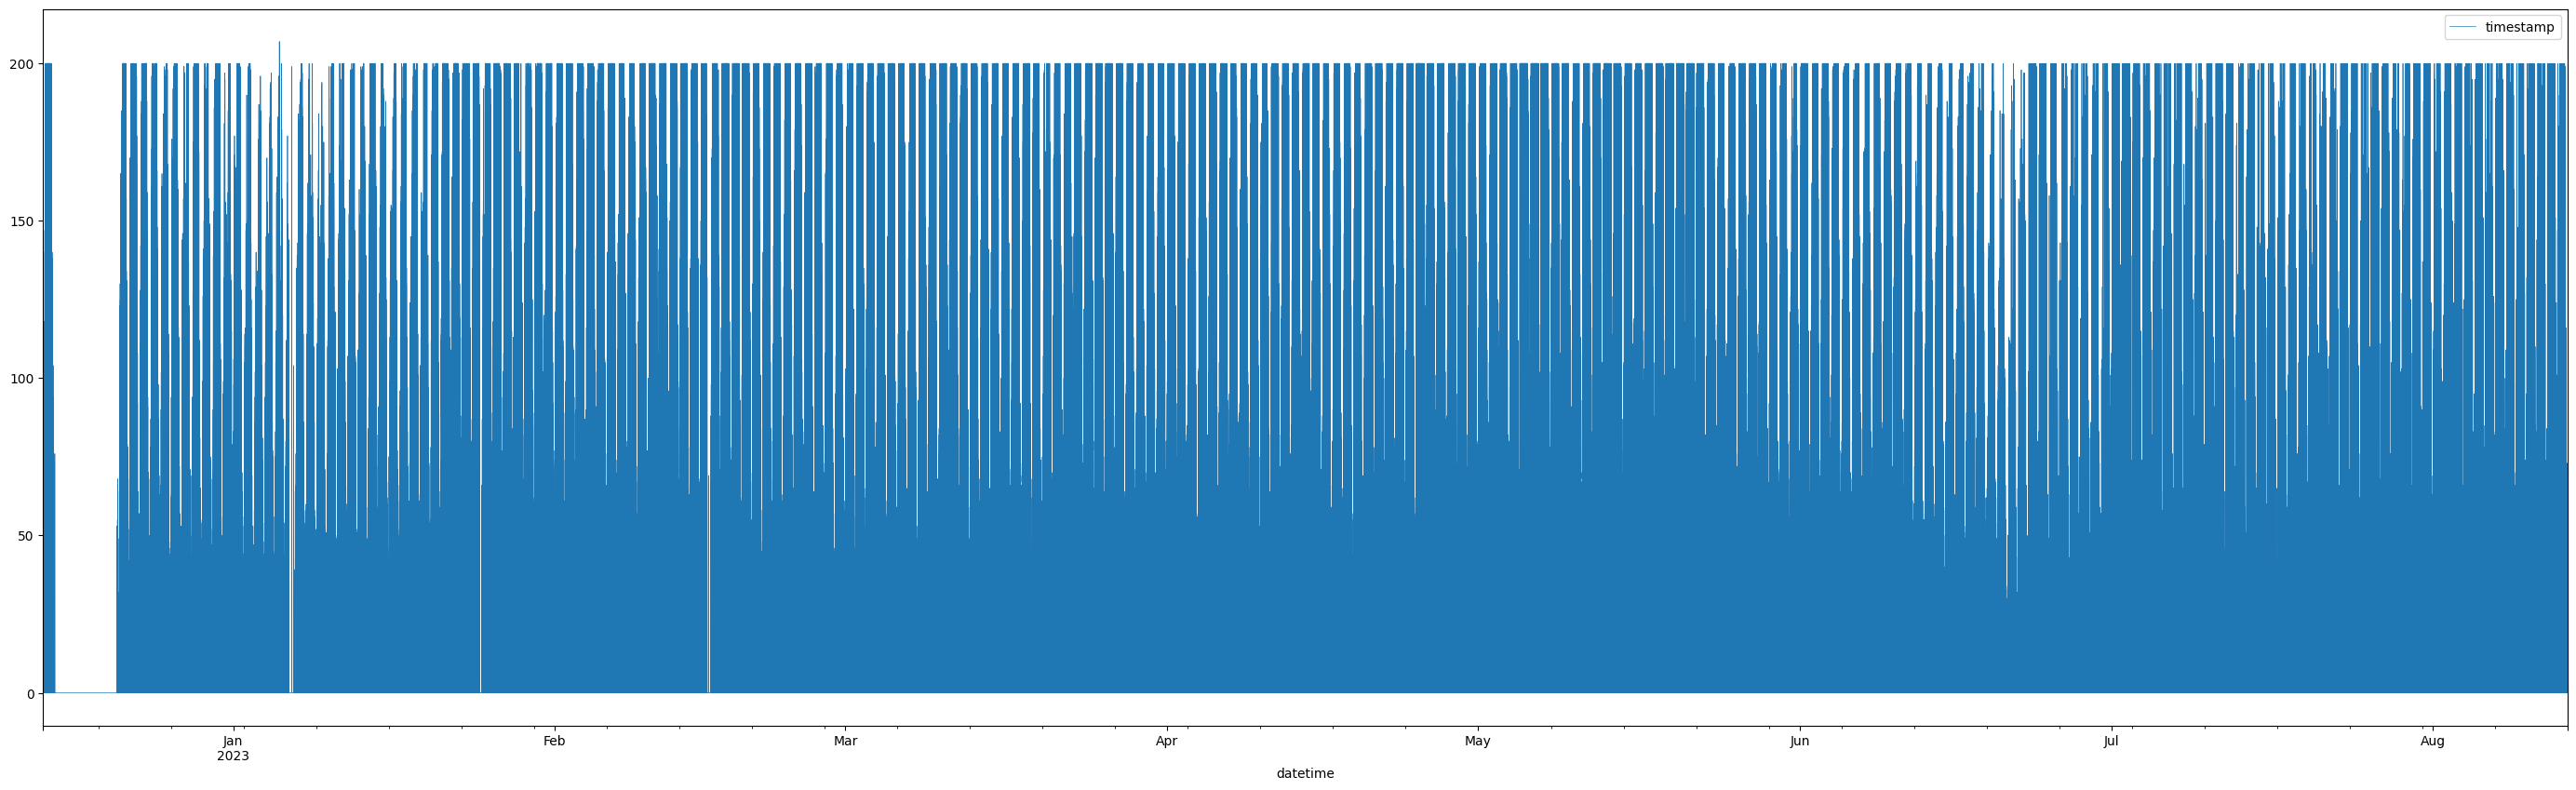

In [3]:
df_purchases['datetime'] = pd.to_datetime(df_purchases['datetime'])
df_purchases.set_index('datetime', inplace=True) # Set datetime as index
df_byminute = df_purchases.resample("1T").count() # group by minute
display(df_byminute.tail(10))
df_byminute.plot(y='timestamp', figsize=(35, 10), lw=0.5) # plot the frequencies. Any of the columns will do

In [5]:
display(df_byminute.tail(100))


,timestamp,user,src,out,time
datetime,,,,,
2023-08-13 21:09:00,0,0,0,0,0
2023-08-13 21:10:00,0,0,0,0,0
2023-08-13 21:11:00,0,0,0,0,0
2023-08-13 21:12:00,0,0,0,0,0
2023-08-13 21:13:00,0,0,0,0,0
...,...,...,...,...,...
2023-08-13 22:44:00,0,0,0,0,0
2023-08-13 22:45:00,37,37,37,37,37
2023-08-13 22:46:00,73,73,73,73,73


## Estimating missing data

Apparently, every 10 minutes, the page with data is refreshed. 200 records are shown at a time. If during a 10 minute interval there are more than 200 purchases, the rest will not be displayed in the web API. 
However, these 200 records not always go from xx:10:00 to xx:59:59, they can comprise any time interval of 10 minutes. Sometimes these intervals are less than 10 minutes, though, but always seem to be 200 lines.

e.g.: If during a 10 minute interval, there's only data for 2 minutes and 20 seconds, we know that there's 7m40s of missing data. The amount of purchases can be extrapolated from the amount of purchases during the first 2m20s.

In [9]:
## This is just an example
# Extrapolate just the 2022-12-13 20:10:00 to 2022-12-13 20:19:59 interval
df_purchases = pd.read_pickle("../processed_dataframes/df_purchases.pkl")
df_purchases['datetime'] = pd.to_datetime(df_purchases['datetime'])
df_purchases.set_index('datetime', inplace=True)

mask = (df_purchases.index >= '2023-08-12 20:10:00') & (df_purchases.index <= '2023-08-12 21:10:00')
df_purchases = df_purchases[mask]
df_bysecond = df_purchases.resample("1s").count() # group by second
missingseconds = (3600-len(df_bysecond))
print(f"Missing seconds during that 1h interval: {missingseconds}")
recordedpurchases = df_bysecond['timestamp'].sum()
print(f"Puchases recorded in that interval: {recordedpurchases}")
purchasespersecond = df_bysecond['timestamp'].sum()/len(df_bysecond)
print(f"Estimated total purchases per second in that interval: {purchasespersecond}")
estimatedpurchases = purchasespersecond * 600
print(f"Estimated total purchases in that interval: {estimatedpurchases}")

Missing seconds during that 1h interval: 3530
Puchases recorded in that interval: 200
Estimated total purchases per second in that interval: 2.857142857142857
Estimated total purchases in that interval: 1714.2857142857142


### Interpolating the data

One way is interpolating the data. For a timeseries dataframe, where each row is a second, we check in which seconds there has not been a purchase (NaN), and we interpolate those values from the available data.

However, this can lead to false data. It is possible that, even on a period where we have data, there are seconds where nobody purchased a lootbox. We don't want to interpolate these. So we set a limit of consecutive missing data before it gets interpolated. That is the `limit_low`.
On the other hand, it is possible that we have periods (e.g. hours or days) of missing data that we could not gather for one reason or another. Those periods should not be interpolated, so we can set another limit, the `limit_high`.

For instance, a `limit_low=60` and a `limit_high=1500` will mean that only periods of consecutive nan between 60 and 1500 seconds will be interpolated.

The interpolate_limit() function takes care of this.

In [10]:
# Interpolates values in a dataframe that only when there's more than x (limit_low) consecutive NaN but less than limit_high consecutive Nan
def interpolate_limit(df, limit_low, limit_high):
    df = df.copy(deep=True) # so it doesn't modify the original df
    notnull = pd.notnull(df).all(axis=1)
    # assign group numbers to the rows of df. Each group starts with a non-null row,
    # followed by null rows
    group = notnull.cumsum()
    # find the index of groups having length > limit
    ignore = (df.groupby(group).filter(lambda grp: ((len(grp)<limit_low) or (len(grp)>limit_high)))).index
    # only ignore rows which are null
    ignore = df.loc[~notnull].index.intersection(ignore)
    keep = df.index.difference(ignore)
    # interpolate only the kept rows
    df.loc[keep] = df.loc[keep].interpolate()

    return df

In [11]:
# Interpolates values in a dataframe that only when there's more than x (limit_low) consecutive NaN but less than limit_high consecutive Nan
def interpolate_limit_rolling(df, limit_low, limit_high):
    df = df.copy(deep=True) # so it doesn't modify the original df
    notnull = pd.notnull(df).all(axis=1)
    # assign group numbers to the rows of df. Each group starts with a non-null row,
    # followed by null rows
    group = notnull.cumsum()
    # find the index of groups having length > limit
    ignore = (df.groupby(group).filter(lambda grp: ((len(grp)<limit_low) or (len(grp)>limit_high)))).index
    # only ignore rows which are null
    ignore = df.loc[~notnull].index.intersection(ignore)
    keep = df.index.difference(ignore)
    # interpolate only the kept rows
    fill_values = (df.ffill()+df.bfill())/2
    print(fill_values)
    fill_values_mean = fill_values.mean()
    print(fill_values_mean)
    fill_values_std = fill_values.std()
    print(fill_values_std)
    df.loc[keep] = df.loc[keep].fillna(fill_values_mean + fill_values_std)


    return df

In [12]:
# Extracts a subset of a dataframe between a start and an end date and time.
def get_df_period(df, startdatetime, enddatetime):
    mask = (df.index >= startdatetime) & (df.index <= enddatetime)
    print(f"Getting dataframe between {startdatetime} and {enddatetime}")
    df_period = df[mask]
    return df_period

In [13]:
# For instance, extract purchases during the last 24h

# Reading purchases dataframe
df_purchases = pd.read_pickle("../processed_dataframes/df_purchases.pkl")
df_purchases['datetime'] = pd.to_datetime(df_purchases['datetime'])
df_purchases.set_index('datetime', inplace=True)

enddate = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S") # right now, to string
startdate = datetime.datetime.strptime(enddate, '%Y-%m-%d %H:%M:%S')
startdate -= datetime.timedelta(seconds=86400) # a day ago
startdate = startdate.strftime("%Y-%m-%d %H:%M:%S") # convert back to string

display(get_df_period(df_purchases, startdate, enddate))

Getting dataframe between 2023-08-12 23:10:46 and 2023-08-13 23:10:46


,timestamp,user,src,out,time
datetime,,,,,
2023-08-12 23:19:28,1691882368,AK***-BNRJ,裂空武器箱,内格夫 | 飞羽,1691882368
2023-08-12 23:19:29,1691882369,AK***-B6UQ,2023年巴黎锦标赛竞争组印花胶囊,印花 | The MongolZ（闪耀）| 2023年巴黎锦标赛,1691882369
2023-08-12 23:19:31,1691882371,A4***-M8TA,2023年巴黎锦标赛竞争组印花胶囊,印花 | BLAST.tv（闪耀）| 2023年巴黎锦标赛,1691882371
2023-08-12 23:19:32,1691882372,AX***-PDUC,2023年巴黎锦标赛竞争组印花胶囊,印花 | Complexity Gaming（闪耀）| 2023年巴黎锦标赛,1691882372
2023-08-12 23:19:33,1691882373,AT***-L9TG,2023年巴黎锦标赛传奇组亲笔签名胶囊,印花 | b1t（全息）| 2023年巴黎锦标赛,1691882373
...,...,...,...,...,...
2023-08-13 22:48:19,1691966899,AL***-U8SA,2023年巴黎锦标赛竞争组亲笔签名胶囊,印花 | frozen | 2023年巴黎锦标赛,1691966899
2023-08-13 22:48:20,1691966900,AU***-Y5QQ,2023年巴黎锦标赛竞争组印花胶囊,印花 | Fluxo | 2023年巴黎锦标赛,1691966900
2023-08-13 22:48:23,1691966903,AU***-Y5QQ,2023年巴黎锦标赛竞争组印花胶囊,印花 | The MongolZ | 2023年巴黎锦标赛,1691966903


In [32]:
# Reading purchases dataframe
df_purchases = pd.read_pickle("../processed_dataframes/df_purchases.pkl")
df_purchases['datetime'] = pd.to_datetime(df_purchases['datetime'])
df_purchases.set_index('datetime', inplace=True)


# Empty dataframe with a row for each second between two datetimes
df2 = pd.DataFrame(0, index=pd.date_range(startdate, enddate, freq="1s"), columns=['values']) # temporary empty df where the index are all seconds on that period
print(df2.shape)
display(df2)

# Extract subset of df_purchases between the start and end dates
df_subset = get_df_period(df_purchases, startdate, enddate)
df_by_second = df_subset.combine_first(df2) # adds 
print(df_by_second.info())
display(df_by_second)
#del df2

# Now resample per second:
df_by_second = df_by_second.resample("1s").count()
df_by_second.replace(0, np.nan, inplace=True) # 0 to NaN
display(df_by_second)

# Traditional interpolation, for comparison
df_by_second_interpolated = df_by_second.copy()
df_by_second_interpolated = df_by_second_interpolated.interpolate(method="linear")
print(df_by_second_interpolated.info())
display(df_by_second_interpolated)

# Apply interpolate_limit()
df_by_second_interpolated_limit = interpolate_limit(df_by_second, 60, 200)
print(df_by_second_interpolated_limit.info())
display(df_by_second_interpolated_limit)


# Apply interpolate_rolling_limit()
df_by_second_interpolated_limit_rolling = interpolate_limit_rolling(df_by_second, 60, 200)
print(df_by_second_interpolated_limit_rolling.info())
display(df_by_second_interpolated_limit_rolling)


(86401, 1)


,values
2023-08-12 23:10:46,0
2023-08-12 23:10:47,0
2023-08-12 23:10:48,0
2023-08-12 23:10:49,0
2023-08-12 23:10:50,0
...,...
2023-08-13 23:10:42,0
2023-08-13 23:10:43,0
2023-08-13 23:10:44,0
2023-08-13 23:10:45,0


Getting dataframe between 2023-08-12 23:10:46 and 2023-08-13 23:10:46
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 90159 entries, 2023-08-12 23:10:46 to 2023-08-13 23:10:46
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   out        4800 non-null   object 
 1   src        4800 non-null   object 
 2   time       4800 non-null   float64
 3   timestamp  4800 non-null   float64
 4   user       4800 non-null   object 
 5   values     90159 non-null  int64  
dtypes: float64(2), int64(1), object(3)
memory usage: 4.8+ MB
None


,out,src,time,timestamp,user,values
2023-08-12 23:10:46,NaN,NaN,NaN,NaN,NaN,0
2023-08-12 23:10:47,NaN,NaN,NaN,NaN,NaN,0
2023-08-12 23:10:48,NaN,NaN,NaN,NaN,NaN,0
2023-08-12 23:10:49,NaN,NaN,NaN,NaN,NaN,0
2023-08-12 23:10:50,NaN,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...
2023-08-13 23:10:42,NaN,NaN,NaN,NaN,NaN,0
2023-08-13 23:10:43,NaN,NaN,NaN,NaN,NaN,0
2023-08-13 23:10:44,NaN,NaN,NaN,NaN,NaN,0
2023-08-13 23:10:45,NaN,NaN,NaN,NaN,NaN,0


,out,src,time,timestamp,user,values
2023-08-12 23:10:46,NaN,NaN,NaN,NaN,NaN,1
2023-08-12 23:10:47,NaN,NaN,NaN,NaN,NaN,1
2023-08-12 23:10:48,NaN,NaN,NaN,NaN,NaN,1
2023-08-12 23:10:49,NaN,NaN,NaN,NaN,NaN,1
2023-08-12 23:10:50,NaN,NaN,NaN,NaN,NaN,1
...,...,...,...,...,...,...
2023-08-13 23:10:42,NaN,NaN,NaN,NaN,NaN,1
2023-08-13 23:10:43,NaN,NaN,NaN,NaN,NaN,1
2023-08-13 23:10:44,NaN,NaN,NaN,NaN,NaN,1
2023-08-13 23:10:45,NaN,NaN,NaN,NaN,NaN,1


...

,out,src,time,timestamp,user,values
2023-08-12 23:10:46,NaN,NaN,NaN,NaN,NaN,1
2023-08-12 23:10:47,NaN,NaN,NaN,NaN,NaN,1
2023-08-12 23:10:48,NaN,NaN,NaN,NaN,NaN,1
2023-08-12 23:10:49,NaN,NaN,NaN,NaN,NaN,1
2023-08-12 23:10:50,NaN,NaN,NaN,NaN,NaN,1
...,...,...,...,...,...,...
2023-08-13 23:10:42,2.0,2.0,2.0,2.0,2.0,1
2023-08-13 23:10:43,2.0,2.0,2.0,2.0,2.0,1
2023-08-13 23:10:44,2.0,2.0,2.0,2.0,2.0,1
2023-08-13 23:10:45,2.0,2.0,2.0,2.0,2.0,1


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 86401 entries, 2023-08-12 23:10:46 to 2023-08-13 23:10:46
Freq: S
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   out        1042 non-null   float64
 1   src        1042 non-null   float64
 2   time       1042 non-null   float64
 3   timestamp  1042 non-null   float64
 4   user       1042 non-null   float64
 5   values     86401 non-null  int64  
dtypes: float64(5), int64(1)
memory usage: 6.6 MB
None


,out,src,time,timestamp,user,values
2023-08-12 23:10:46,NaN,NaN,NaN,NaN,NaN,1
2023-08-12 23:10:47,NaN,NaN,NaN,NaN,NaN,1
2023-08-12 23:10:48,NaN,NaN,NaN,NaN,NaN,1
2023-08-12 23:10:49,NaN,NaN,NaN,NaN,NaN,1
2023-08-12 23:10:50,NaN,NaN,NaN,NaN,NaN,1
...,...,...,...,...,...,...
2023-08-13 23:10:42,NaN,NaN,NaN,NaN,NaN,1
2023-08-13 23:10:43,NaN,NaN,NaN,NaN,NaN,1
2023-08-13 23:10:44,NaN,NaN,NaN,NaN,NaN,1
2023-08-13 23:10:45,NaN,NaN,NaN,NaN,NaN,1


                     out  src  time  timestamp  user  values
2023-08-12 23:10:46  NaN  NaN   NaN        NaN   NaN     1.0
2023-08-12 23:10:47  NaN  NaN   NaN        NaN   NaN     1.0
2023-08-12 23:10:48  NaN  NaN   NaN        NaN   NaN     1.0
2023-08-12 23:10:49  NaN  NaN   NaN        NaN   NaN     1.0
2023-08-12 23:10:50  NaN  NaN   NaN        NaN   NaN     1.0
...                  ...  ...   ...        ...   ...     ...
2023-08-13 23:10:42  NaN  NaN   NaN        NaN   NaN     1.0
2023-08-13 23:10:43  NaN  NaN   NaN        NaN   NaN     1.0
2023-08-13 23:10:44  NaN  NaN   NaN        NaN   NaN     1.0
2023-08-13 23:10:45  NaN  NaN   NaN        NaN   NaN     1.0
2023-08-13 23:10:46  NaN  NaN   NaN        NaN   NaN     1.0

[86401 rows x 6 columns]
out          5.546044
src          5.546044
time         5.546044
timestamp    5.546044
user         5.546044
values       1.043495
dtype: float64
out          3.525719
src          3.525719
time         3.525719
timestamp    3.525719
user   

,out,src,time,timestamp,user,values
2023-08-12 23:10:46,NaN,NaN,NaN,NaN,NaN,1
2023-08-12 23:10:47,NaN,NaN,NaN,NaN,NaN,1
2023-08-12 23:10:48,NaN,NaN,NaN,NaN,NaN,1
2023-08-12 23:10:49,NaN,NaN,NaN,NaN,NaN,1
2023-08-12 23:10:50,NaN,NaN,NaN,NaN,NaN,1
...,...,...,...,...,...,...
2023-08-13 23:10:42,NaN,NaN,NaN,NaN,NaN,1
2023-08-13 23:10:43,NaN,NaN,NaN,NaN,NaN,1
2023-08-13 23:10:44,NaN,NaN,NaN,NaN,NaN,1
2023-08-13 23:10:45,NaN,NaN,NaN,NaN,NaN,1


In [33]:
# try to extrapolate the missing values in df_byminute
import numpy as np
df_byminute.replace(0, np.nan, inplace=True)
df_byminute_extrapolated_linear = df_byminute.interpolate(method="linear")

# same, by second
df_by_second.replace(0, np.nan, inplace=True)
df_by_second_extrapolated_linear = df_by_second.interpolate(method="linear")

<AxesSubplot: title={'center': 'by 20 min, original data vs interpolated vs interpolated_limit'}>

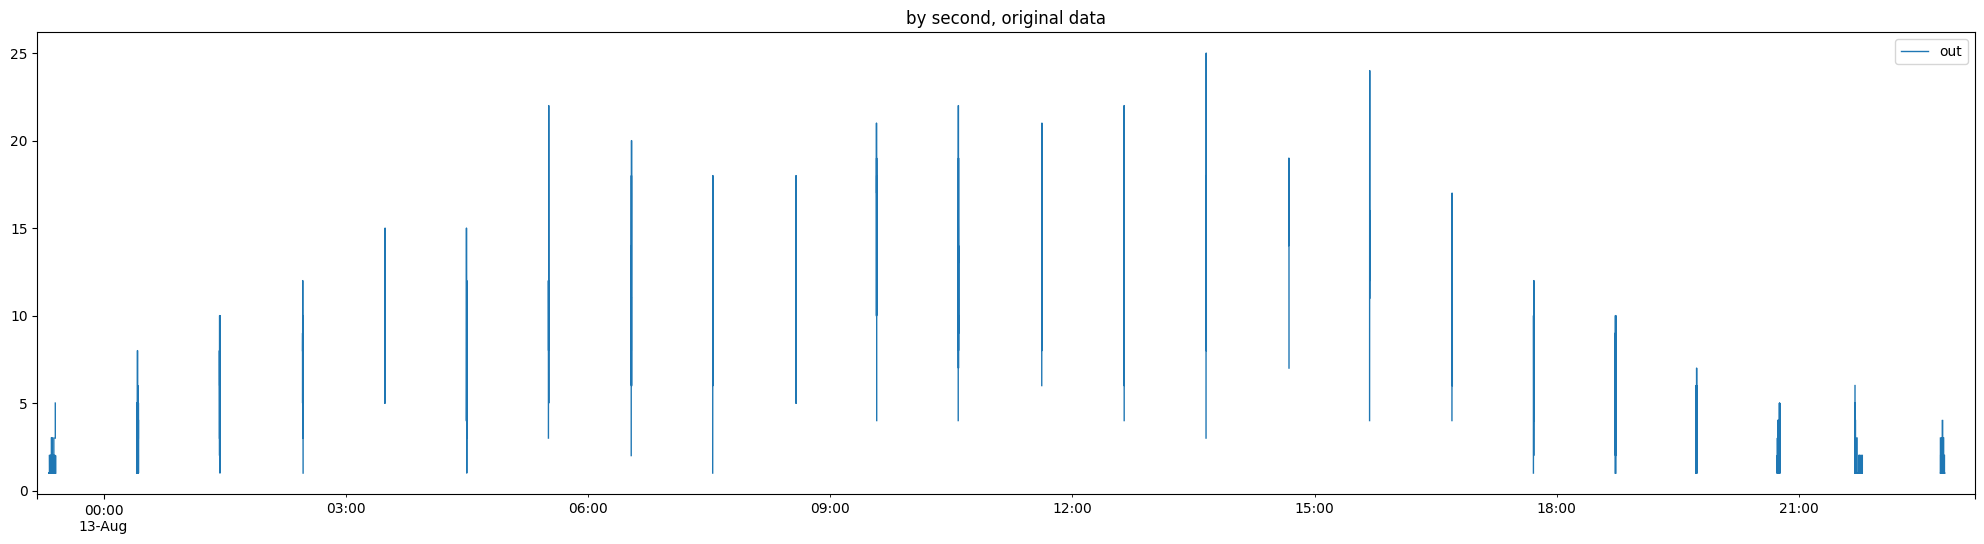

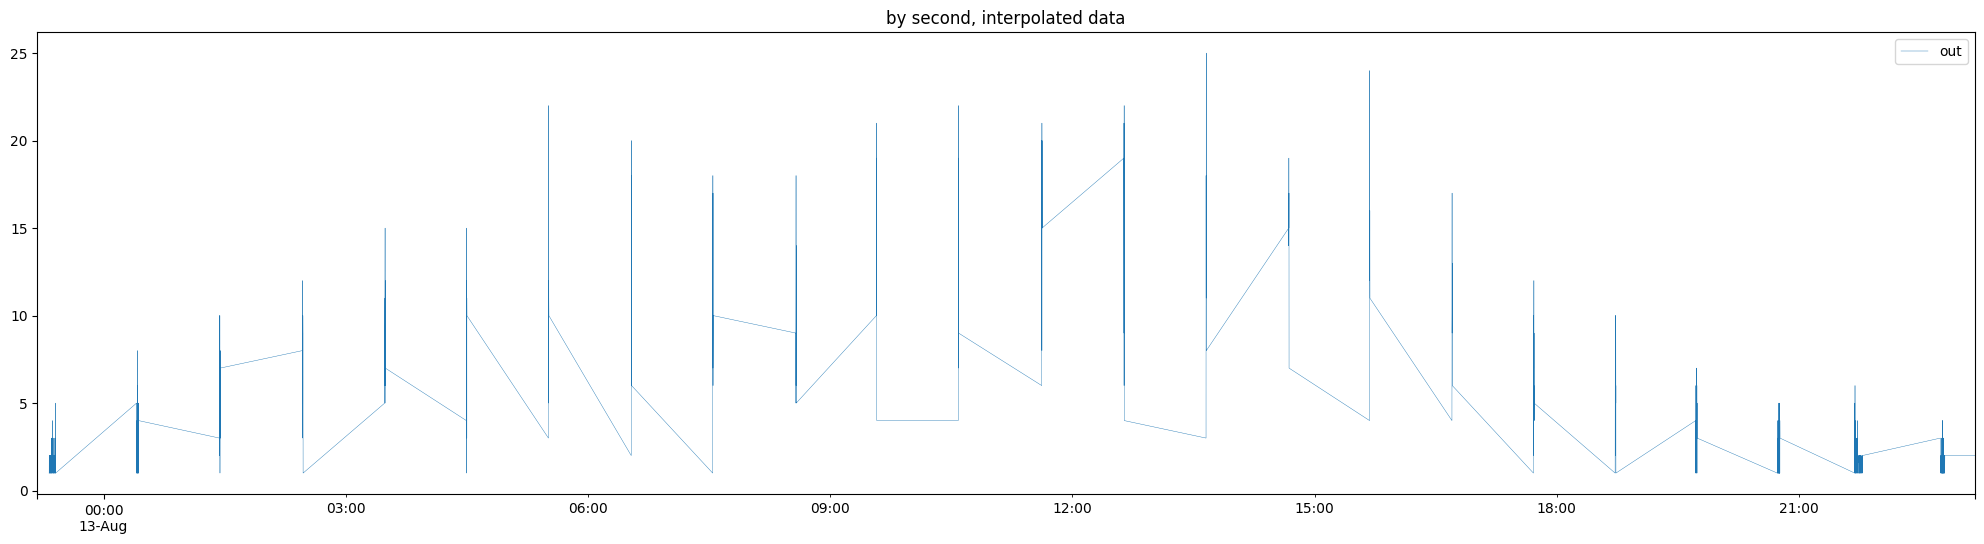

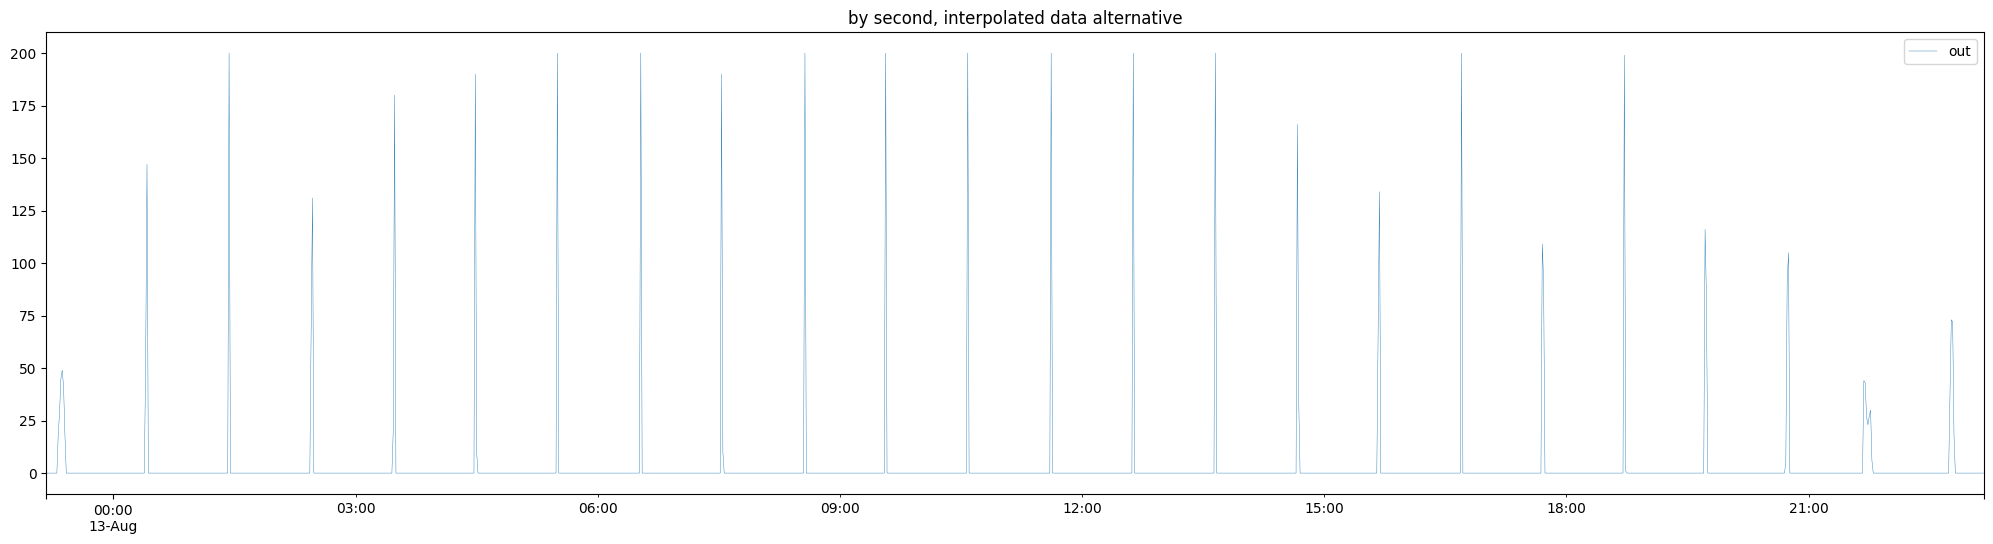

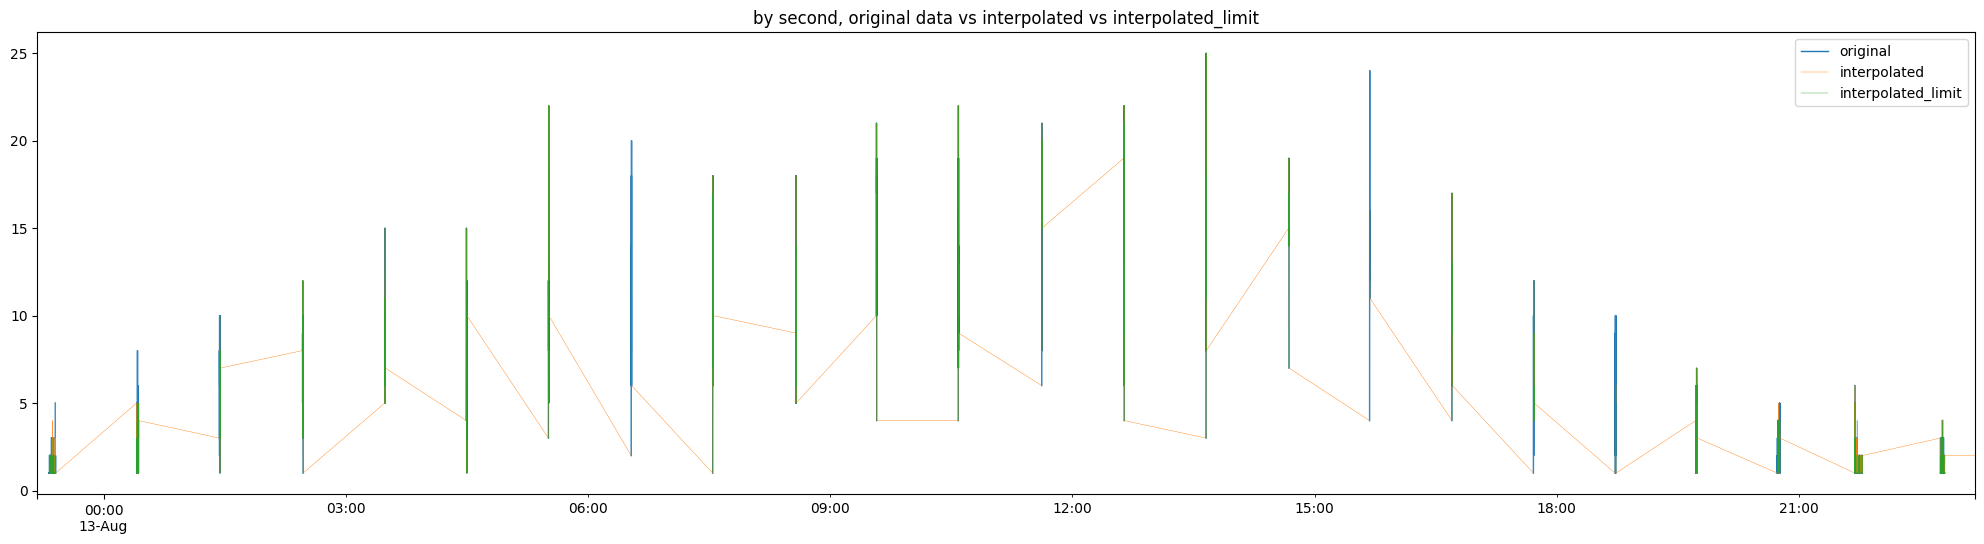

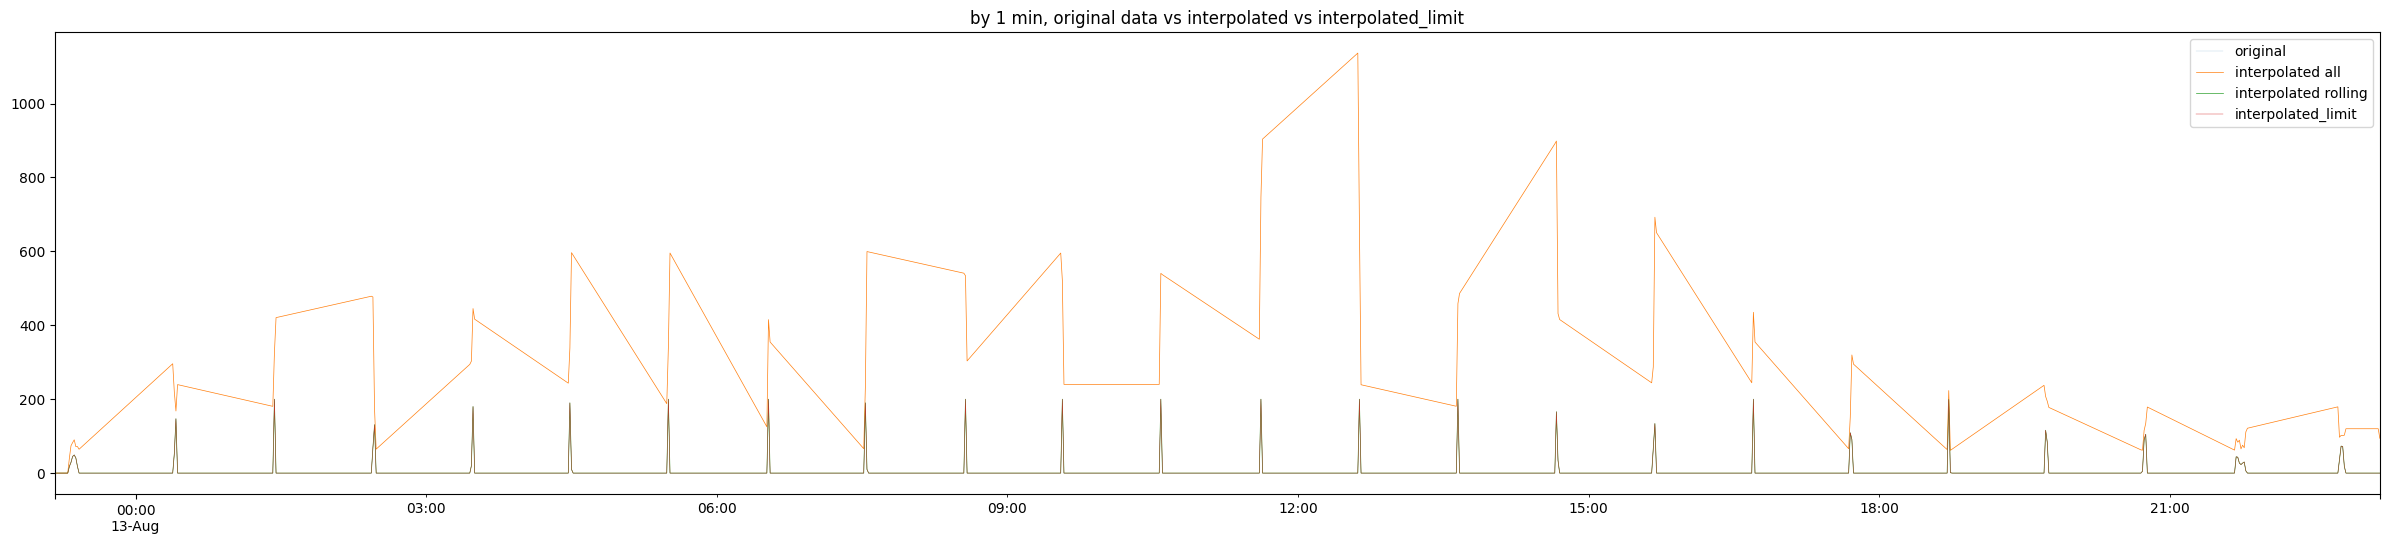

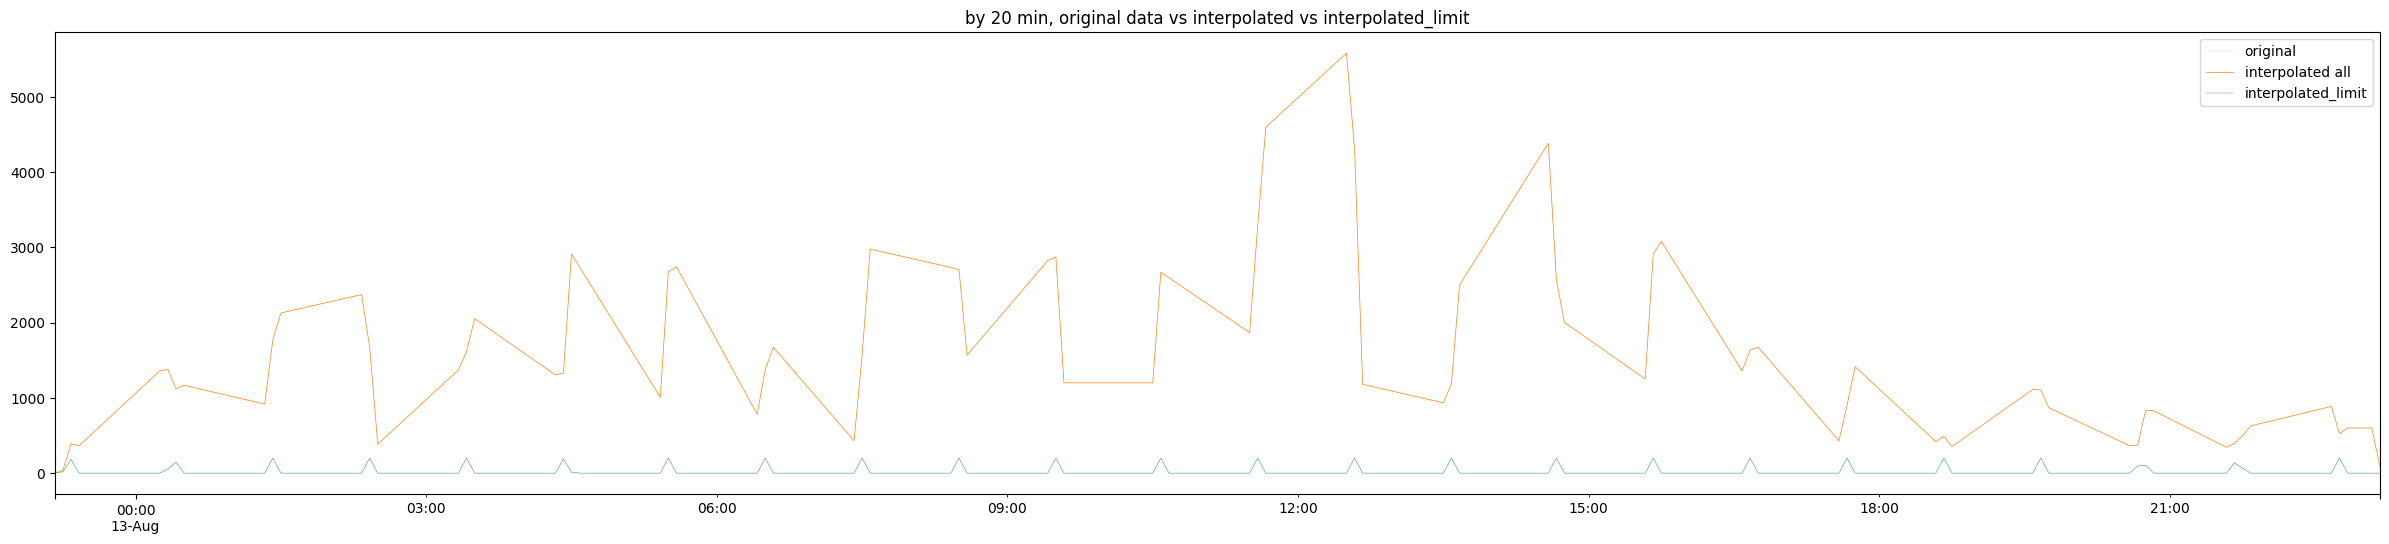

In [36]:
# Plot these differences, gruped per 10 minutes (so it's more visible)

df_by_second.plot(y='out', figsize=(25, 6), lw=1, title="by second, original data")
df_by_second_interpolated.plot(y='out', figsize=(25, 6), lw=0.3, title="by second, interpolated data")
df_by_second_interpolated_limit_rolling.plot(y='out', figsize=(25, 6), lw=0.3, title="by second, interpolated data alternative")
ax = df_by_second.plot(y='out', lw=1, label='original')
ax = df_by_second_interpolated.plot(ax=ax, y='out', lw=0.3, label='interpolated') 
df_by_second_interpolated_limit.plot(ax=ax, y='out', lw=0.3, figsize=(25, 6), label='interpolated_limit', title="by second, original data vs interpolated vs interpolated_limit")


# regrouped, from second to 1 minute
df_byminute = df_by_second.resample("1T").sum()
df_byminute_interpolated = df_by_second_interpolated.resample("1T").sum()
df_byminute_interpolated_limit = df_by_second_interpolated_limit.resample("1T").sum()
df_by_second_interpolated_limit_rolling = df_by_second_interpolated_limit_rolling.resample("1T").sum()

#df_byminute_.plot(y='out', figsize=(25, 6), lw=0.3, title="by minute, resampled from interpolated by second data")
ax = df_byminute.plot(y='out', lw=0.1, label='original')
ax = df_byminute_interpolated.plot(ax=ax, y='out', lw=0.5, label='interpolated all')
ax = df_by_second_interpolated_limit_rolling.plot(ax=ax, y='out', lw=0.5, label='interpolated rolling')
df_byminute_interpolated_limit.plot(ax=ax, y='out', figsize=(30, 6), lw=0.3, label='interpolated_limit', title="by 1 min, original data vs interpolated vs interpolated_limit")

# regrouped, from second to 10 minute
df_byminute = df_by_second.resample("5T").sum()
df_byminute_interpolated = df_by_second_interpolated.resample("5T").sum()
df_byminute_interpolated_limit = df_by_second_interpolated_limit.resample("5T").sum()
#df_byminute_.plot(y='out', figsize=(25, 6), lw=0.3, title="by minute, resampled from interpolated by second data")
ax = df_byminute.plot(y='out', lw=0.1, label='original')
ax = df_byminute_interpolated.plot(ax=ax, y='out', lw=0.5, label='interpolated all')
df_byminute_interpolated_limit.plot(ax=ax, y='out', figsize=(30, 6), lw=0.3, label='interpolated_limit', title="by 20 min, original data vs interpolated vs interpolated_limit")